In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

from IPython.display import display

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

print("File uploaded successfully!")

Saving ApexPlanet_DataAnalytics_Dataset (2).xlsx to ApexPlanet_DataAnalytics_Dataset (2) (1).xlsx
File uploaded successfully!


In [4]:
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, sheet_name="Sales_Dataset")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1000
Columns: 12


In [5]:
display(df.head(10))

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90
5,ORD100007,2025-12-31,CUST3952,Customer_71,40.0,Female,Hyderabad,Laptop,Electronics,9,35947.47,323527.23
6,ORD100008,2025-10-14,CUST1758,Customer_335,61.0,Male,Patna,Mobile,Electronics,6,49997.53,299985.18
7,ORD100009,2025-12-05,CUST9622,Customer_224,35.0,Male,Kolkata,Laptop,Electronics,3,9488.83,28466.49
8,ORD100010,2025-11-21,CUST9770,Customer_494,41.0,Female,Mumbai,Book,Education,6,19488.23,116929.38
9,ORD100011,2025-04-16,CUST1312,Customer_40,30.0,Male,Kolkata,Mobile,Electronics,8,18024.34,144194.72


In [6]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(1000, 12)

Column Names:
['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Total_Sales']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


In [7]:
missing_values = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing_values)

,Column,Missing Values,Missing Percentage
Order_ID,Order_ID,0,0.0
Order_Date,Order_Date,0,0.0
Customer_ID,Customer_ID,0,0.0
Customer_Name,Customer_Name,0,0.0
Age,Age,20,2.0
Gender,Gender,0,0.0
City,City,13,1.3
Product,Product,0,0.0
Category,Category,0,0.0
Quantity,Quantity,0,0.0


In [8]:
numerical_summary = df.describe()

display(numerical_summary)

,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


In [9]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.month_name()
df["Year_Month"] = df["Order_Date"].dt.to_period("M").astype(str)

display(df.head())

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Year,Month,Month_Name,Year_Month
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,February,2025-02
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,October,2025-10
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,May,2025-05
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,December,2025-12
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,November,2025-11


In [10]:
categorical_columns = [
    "Gender",
    "City",
    "Product",
    "Category"
]

for col in categorical_columns:
    print("\n" + "="*50)
    print(f"{col} Distribution")
    print("="*50)
    print(df[col].value_counts(dropna=False))


Gender Distribution
Gender
Male      511
Female    489
Name: count, dtype: int64

City Distribution
City
Patna        135
Kolkata      133
Mumbai       131
Delhi        125
Hyderabad    125
Bengaluru    122
Gaya         117
Pune          99
NaN           13
Name: count, dtype: int64

Product Distribution
Product
Mobile    184
Book      178
Laptop    170
Chair     159
Shoes     156
Rice      153
Name: count, dtype: int64

Category Distribution
Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64


In [11]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.month_name()
df["Year_Month"] = df["Order_Date"].dt.to_period("M").astype(str)

display(df.head())

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Year,Month,Month_Name,Year_Month
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,February,2025-02
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,October,2025-10
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,May,2025-05
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,December,2025-12
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,November,2025-11


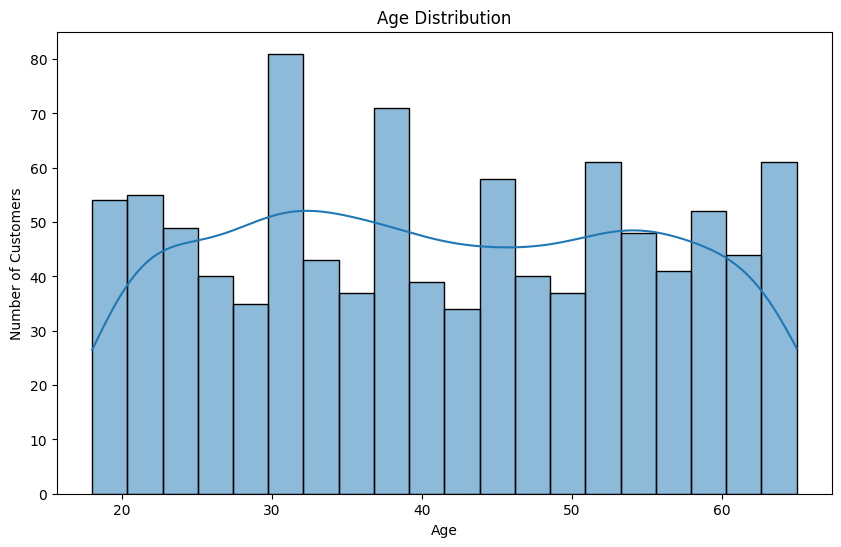

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Age"].dropna(), bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

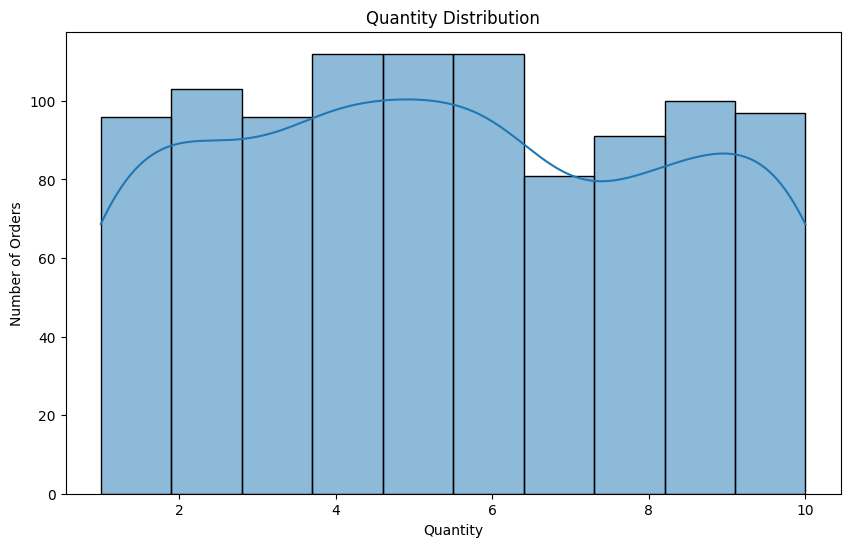

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Quantity"], bins=10, kde=True)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")

plt.show()

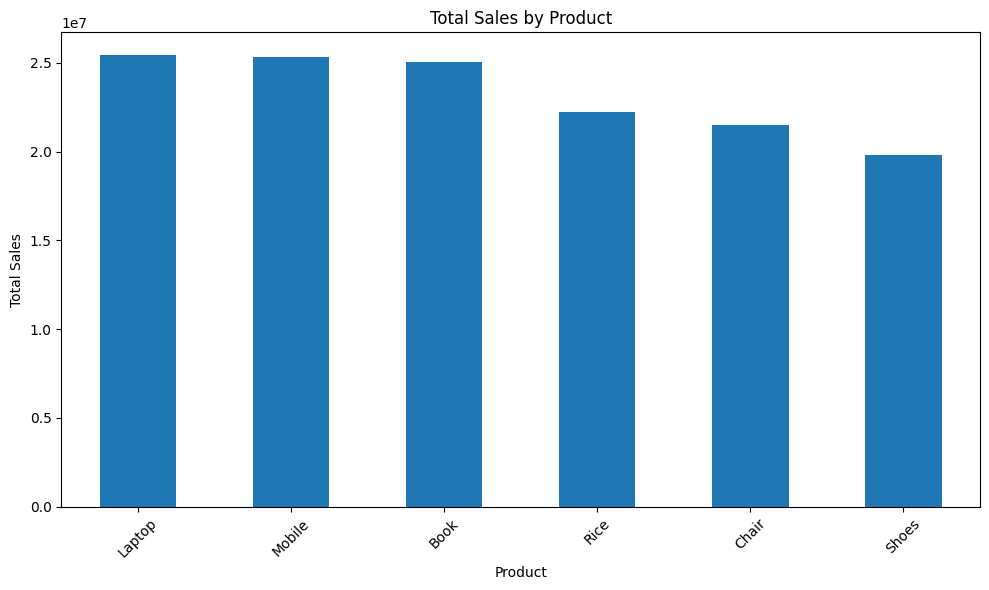

In [14]:
product_sales = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

product_sales.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

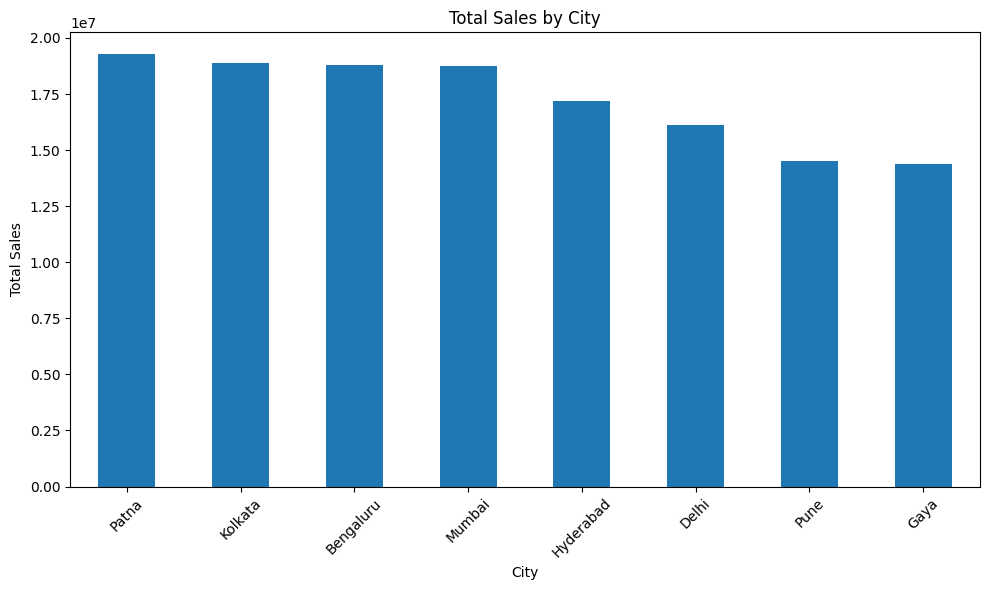

In [15]:
city_sales = (
    df.groupby("City")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

city_sales.plot(kind="bar")

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
# Create SQLite database

conn = sqlite3.connect("ApexPlanet_Task2_Sales.db")

# Save dataframe as SQL table
df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("SQL database created successfully!")

SQL database created successfully!


In [17]:
query1 = """
SELECT
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales;
"""

result1 = pd.read_sql_query(query1, conn)

display(result1)

,Total_Revenue
0,1.393994e+08


In [18]:
query3 = """
SELECT
    Year_Month,
    ROUND(SUM(Total_Sales), 2) AS Monthly_Revenue
FROM sales
GROUP BY Year_Month
ORDER BY Year_Month;
"""

result3 = pd.read_sql_query(query3, conn)

display(result3)

,Year_Month,Monthly_Revenue
0,2025-01,10096190.73
1,2025-02,11511181.46
2,2025-03,13059899.94
3,2025-04,12222700.17
4,2025-05,10984689.25
5,2025-06,12912332.64
6,2025-07,11746226.80
7,2025-08,9448471.22
8,2025-09,9179896.29
9,2025-10,12500936.50


In [19]:
query7 = """
SELECT
    Gender,
    COUNT(Order_ID) AS Number_of_Orders,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue,
    ROUND(AVG(Total_Sales), 2) AS Average_Order_Value
FROM sales
GROUP BY Gender
ORDER BY Total_Revenue DESC;
"""

result7 = pd.read_sql_query(query7, conn)

display(result7)

,Gender,Number_of_Orders,Total_Revenue,Average_Order_Value
0,Male,511,72463550.63,141807.34
1,Female,489,66935889.02,136883.21


In [21]:
sql_results = {
    "Q1_Total_Revenue": result1,
    "Q3_Monthly_Sales": result3,
    "Q7_Gender_Revenue": result7
}

with pd.ExcelWriter(
    "ApexPlanet_Task2_SQL_Results.xlsx",
    engine="openpyxl"
) as writer:

    for sheet_name, result in sql_results.items():
        result.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False
        )

print("SQL results exported successfully!")

SQL results exported successfully!


In [22]:
sql_script = """
-- ApexPlanet Data Analytics Internship
-- Task 2: Exploratory Data Analysis & Business Intelligence

-- Q1. What is the total revenue generated?
SELECT ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales;

-- Q2. What are the top 5 products by revenue?
SELECT Product,
       ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales
GROUP BY Product
ORDER BY Total_Revenue DESC
LIMIT 5;

-- Q3. What is the monthly sales trend?
SELECT Year_Month,
       ROUND(SUM(Total_Sales), 2) AS Monthly_Revenue
FROM sales
GROUP BY Year_Month
ORDER BY Year_Month;

-- Q4. Which cities generate the highest revenue?
SELECT City,
       ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales
WHERE City IS NOT NULL
GROUP BY City
ORDER BY Total_Revenue DESC;

-- Q5. Which product categories generate the most revenue?
SELECT Category,
       ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales
GROUP BY Category
ORDER BY Total_Revenue DESC;

-- Q6. What is the average order value by category?
SELECT Category,
       COUNT(Order_ID) AS Number_of_Orders,
       ROUND(AVG(Total_Sales), 2) AS Average_Order_Value
FROM sales
GROUP BY Category
ORDER BY Average_Order_Value DESC;

-- Q7. Which gender contributes the most revenue?
SELECT Gender,
       COUNT(Order_ID) AS Number_of_Orders,
       ROUND(SUM(Total_Sales), 2) AS Total_Revenue,
       ROUND(AVG(Total_Sales), 2) AS Average_Order_Value
FROM sales
GROUP BY Gender
ORDER BY Total_Revenue DESC;
"""

with open(
    "ApexPlanet_Task2_SQL_Queries.sql",
    "w"
) as f:
    f.write(sql_script)

print("SQL file created successfully!")

SQL file created successfully!


In [23]:
numeric_columns = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Total_Sales"
]

correlation = df[numeric_columns].corr()

display(correlation)

,Age,Quantity,Unit_Price,Total_Sales
Age,1.000000,-0.027628,-0.012214,0.001479
Quantity,-0.027628,1.000000,0.021855,0.646641
Unit_Price,-0.012214,0.021855,1.000000,0.686303
Total_Sales,0.001479,0.646641,0.686303,1.000000


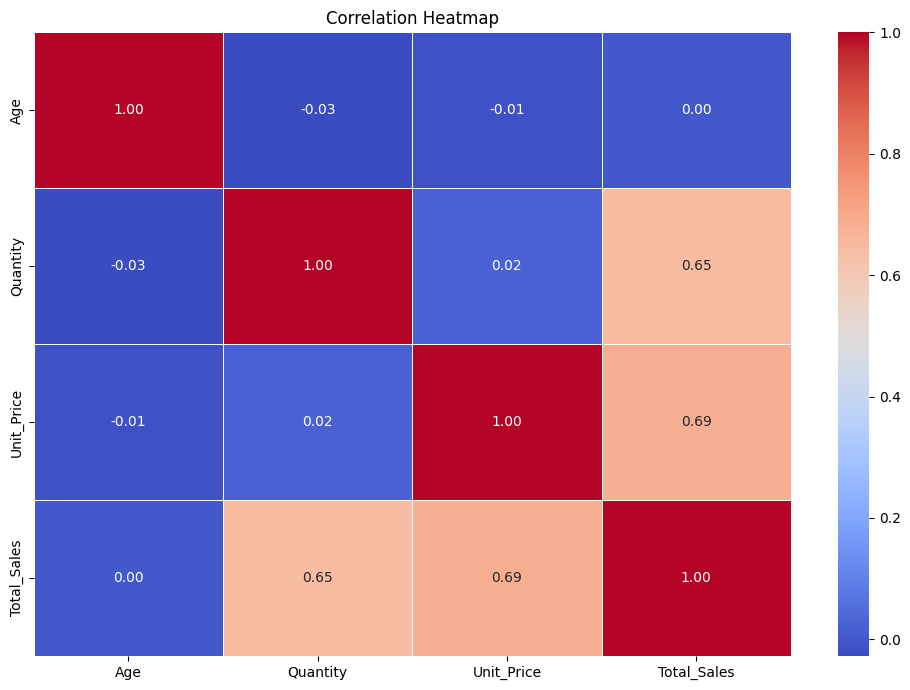

In [24]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

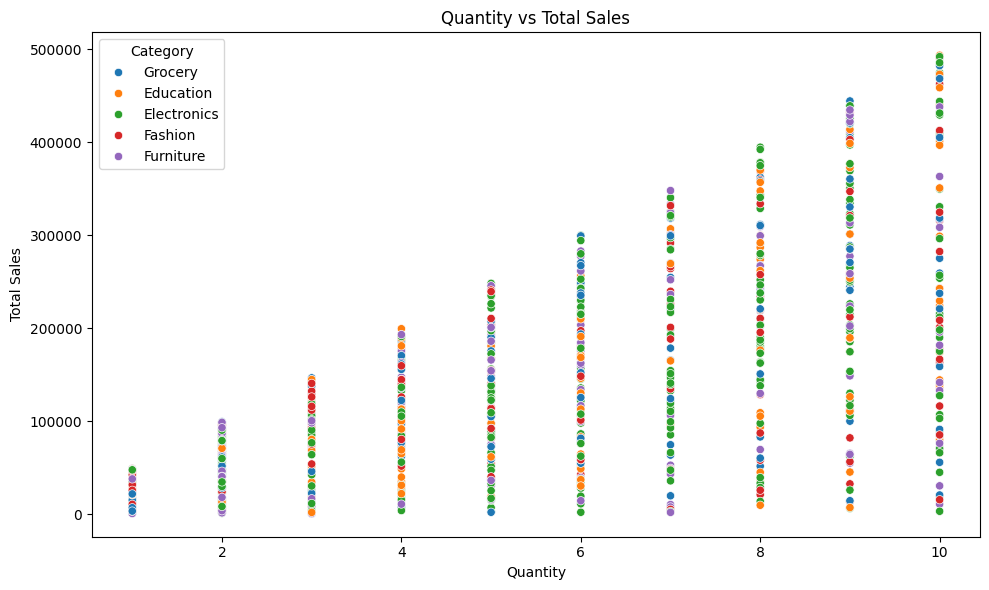

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total_Sales",
    hue="Category"
)

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

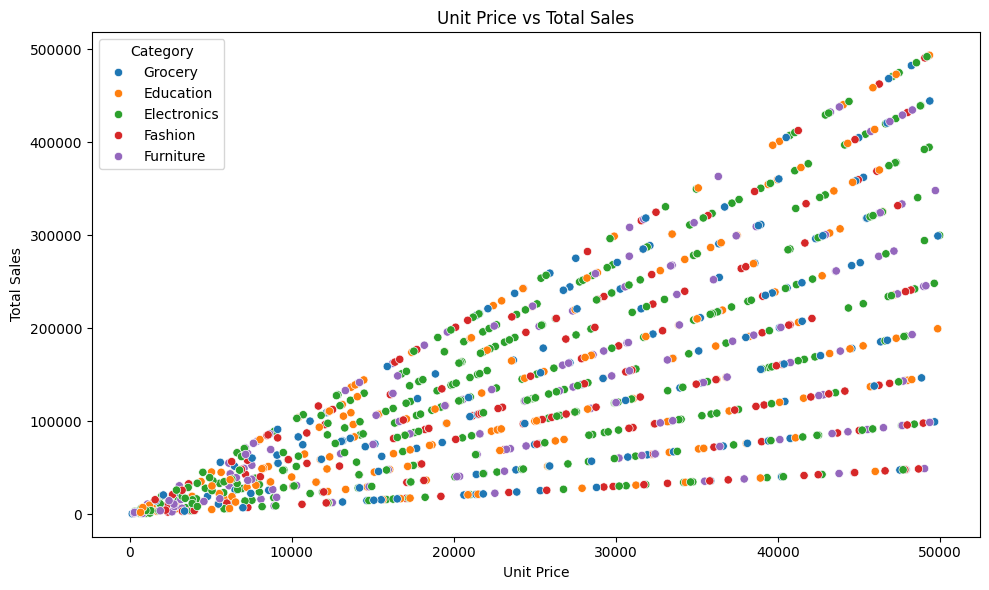

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Unit_Price",
    y="Total_Sales",
    hue="Category"
)

plt.title("Unit Price vs Total Sales")
plt.xlabel("Unit Price")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

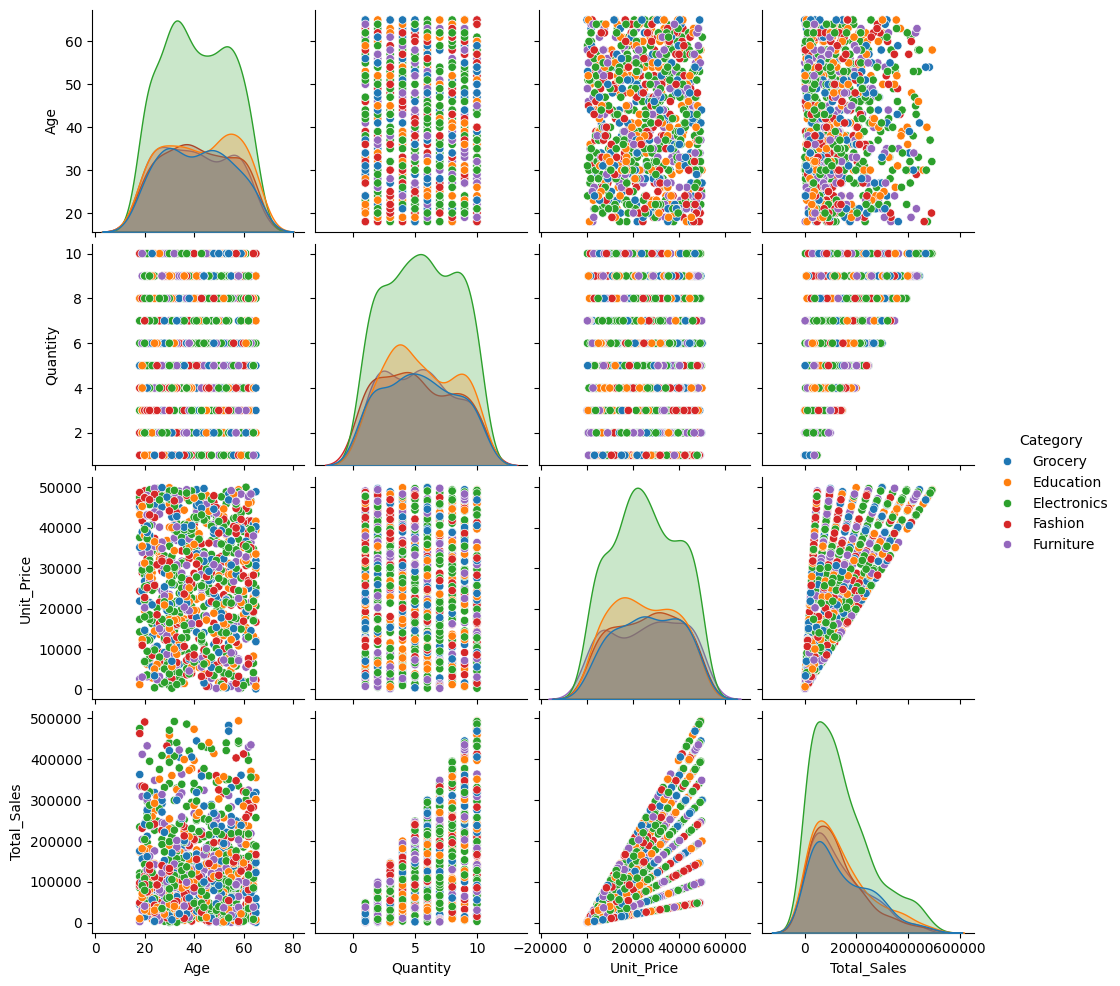

In [27]:
pairplot_data = df[
    ["Age", "Quantity", "Unit_Price", "Total_Sales", "Category"]
].dropna()

sns.pairplot(
    pairplot_data,
    hue="Category"
)

plt.show()

In [28]:
total_revenue = df["Total_Sales"].sum()
total_orders = df["Order_ID"].nunique()
average_order_value = df["Total_Sales"].mean()

top_category = (
    df.groupby("Category")["Total_Sales"]
    .sum()
    .idxmax()
)

top_product = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .idxmax()
)

top_city = (
    df.groupby("City")["Total_Sales"]
    .sum()
    .idxmax()
)

print("========== KEY BUSINESS METRICS ==========")

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Top Category: {top_category}")
print(f"Top Product: {top_product}")
print(f"Top City: {top_city}")

========== KEY BUSINESS METRICS ==========
Total Revenue: ₹139,399,439.65
Total Orders: 992
Average Order Value: ₹139,399.44
Top Category: Electronics
Top Product: Laptop
Top City: Patna


In [29]:
category_revenue = (
    df.groupby("Category")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

city_revenue = (
    df.groupby("City")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

monthly_revenue = (
    df.groupby("Year_Month")["Total_Sales"]
    .sum()
)

print("========== BUSINESS INSIGHTS ==========\n")

print(
    f"1. {category_revenue.index[0]} is the highest-revenue category, "
    f"generating ₹{category_revenue.iloc[0]:,.2f}."
)

print(
    f"2. {product_revenue.index[0]} is the top-performing product, "
    f"generating ₹{product_revenue.iloc[0]:,.2f}."
)

print(
    f"3. {city_revenue.index[0]} is the highest-revenue city, "
    f"generating ₹{city_revenue.iloc[0]:,.2f}."
)

best_month = monthly_revenue.idxmax()

print(
    f"4. {best_month} recorded the highest monthly revenue "
    f"of ₹{monthly_revenue.max():,.2f}."
)

print(
    f"5. The average order value is "
    f"₹{df['Total_Sales'].mean():,.2f}."
)

========== BUSINESS INSIGHTS ==========

1. Electronics is the highest-revenue category, generating ₹50,778,581.70.
2. Laptop is the top-performing product, generating ₹25,443,008.51.
3. Patna is the highest-revenue city, generating ₹19,285,966.89.
4. 2025-03 recorded the highest monthly revenue of ₹13,059,899.94.
5. The average order value is ₹139,399.44.


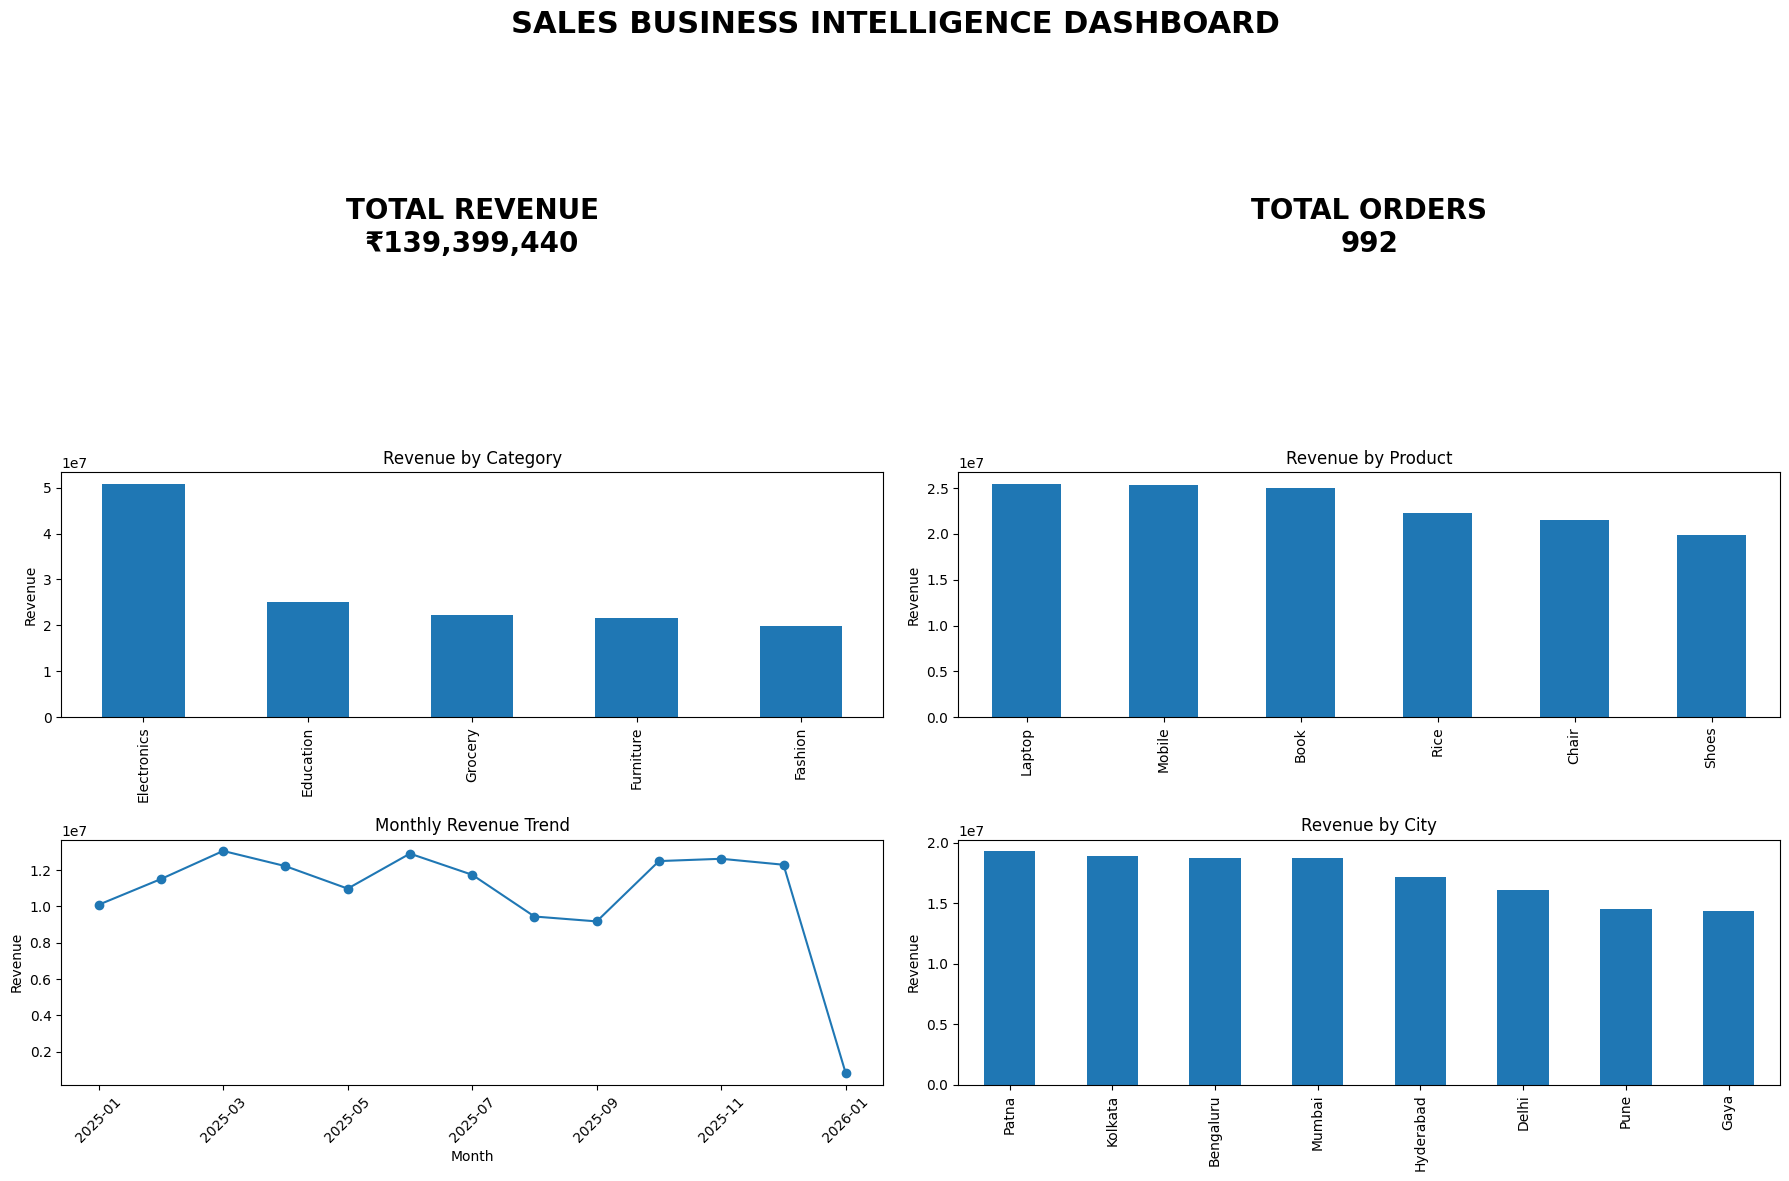

In [30]:
fig = plt.figure(figsize=(18, 12))

# Main title
fig.suptitle(
    "SALES BUSINESS INTELLIGENCE DASHBOARD",
    fontsize=22,
    fontweight="bold"
)

# KPI 1
ax1 = plt.subplot(3, 2, 1)
ax1.axis("off")

ax1.text(
    0.5,
    0.5,
    f"TOTAL REVENUE\n₹{total_revenue:,.0f}",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)

# KPI 2
ax2 = plt.subplot(3, 2, 2)
ax2.axis("off")

ax2.text(
    0.5,
    0.5,
    f"TOTAL ORDERS\n{total_orders:,}",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)

# Category chart
ax3 = plt.subplot(3, 2, 3)

category_revenue.plot(
    kind="bar",
    ax=ax3
)

ax3.set_title("Revenue by Category")
ax3.set_xlabel("")
ax3.set_ylabel("Revenue")

# Product chart
ax4 = plt.subplot(3, 2, 4)

product_revenue.plot(
    kind="bar",
    ax=ax4
)

ax4.set_title("Revenue by Product")
ax4.set_xlabel("")
ax4.set_ylabel("Revenue")

# Monthly trend
ax5 = plt.subplot(3, 2, 5)

monthly_revenue.plot(
    marker="o",
    ax=ax5
)

ax5.set_title("Monthly Revenue Trend")
ax5.set_xlabel("Month")
ax5.set_ylabel("Revenue")

ax5.tick_params(axis="x", rotation=45)

# City chart
ax6 = plt.subplot(3, 2, 6)

city_revenue.plot(
    kind="bar",
    ax=ax6
)

ax6.set_title("Revenue by City")
ax6.set_xlabel("")
ax6.set_ylabel("Revenue")

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "ApexPlanet_Task2_Dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
top_customers = (
    df.groupby(["Customer_ID", "Customer_Name"])["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values(by="Total_Sales", ascending=False)
    .head(10)
)

with pd.ExcelWriter(
    "ApexPlanet_Task2_EDA_Report.xlsx",
    engine="openpyxl"
) as writer:

    df.describe().to_excel(
        writer,
        sheet_name="Descriptive_Statistics"
    )

    missing_values.to_excel(
        writer,
        sheet_name="Missing_Values",
        index=False
    )

    category_revenue.to_frame(
        "Total_Sales"
    ).to_excel(
        writer,
        sheet_name="Category_Analysis"
    )

    product_revenue.to_frame(
        "Total_Sales"
    ).to_excel(
        writer,
        sheet_name="Product_Analysis"
    )

    city_revenue.to_frame(
        "Total_Sales"
    ).to_excel(
        writer,
        sheet_name="City_Analysis"
    )

    monthly_revenue.to_frame(
        "Total_Sales"
    ).to_excel(
        writer,
        sheet_name="Monthly_Analysis"
    )

    correlation.to_excel(
        writer,
        sheet_name="Correlation"
    )

    top_customers.to_excel(
        writer,
        sheet_name="Top_Customers",
        index=False
    )

print("EDA report created successfully!")

EDA report created successfully!


In [35]:
conn.close()

print("SQL connection closed.")

SQL connection closed.


In [36]:
import os

for file in os.listdir():
    if file.startswith("ApexPlanet_Task2"):
        print(file)

ApexPlanet_Task2_Dashboard.png
ApexPlanet_Task2_EDA_Report.xlsx
ApexPlanet_Task2_SQL_Results.xlsx
ApexPlanet_Task2_SQL_Queries.sql
ApexPlanet_Task2_Sales.db


In [37]:
from google.colab import files

files.download("ApexPlanet_Task2_EDA_Report.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>